# Rigorous Statistical Evaluation of Dual-Signal SBFL on ProofWriter-NL depth-3

This notebook demonstrates the full evaluation pipeline for **Dual-Signal SBFL** (Spectrum-Based Fault Localization) and four baseline methods on ProofWriter-NL depth-3 multi-hop deduction examples.

**What this artifact does:**
- Evaluates 5 methods (dual_sbfl, one_shot, cot, self_refine, flat_sbfl) on ProofWriter-NL reasoning
- Computes multi-hop deduction accuracy with 95% bootstrap CIs and Cohen's h effect sizes
- Measures KB hallucination rates, fuzzy/strict atomic fact recall, and LLM efficiency
- Generates 7 matplotlib figures summarizing all results

**Demo mode:** This notebook loads 3 pre-computed examples from `mini_demo_data.json` and re-runs the metrics computation and figure generation — skipping the expensive LLM pipeline steps. Config parameters are set to minimum values; see the Config cell to scale up.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru, requests — NOT pre-installed on Colab
_pip('loguru==0.7.3')
_pip('requests==2.32.4')

# Core scientific packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0', 'scipy==1.16.3')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

All imports from the original eval.py script, plus matplotlib display helpers for the notebook.

In [2]:
import gc
import json
import math
import os
import random
import re
import resource
import sys
import tempfile
import time
from collections import Counter
from pathlib import Path
from typing import Any

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import requests
from loguru import logger
from scipy import stats

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Data Loading

Loads `mini_demo_data.json` — a curated subset of 3 ProofWriter-NL depth-3 examples with pre-computed evaluation results for all 5 methods. Falls back to the GitHub URL when running in Colab.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-d8d250-dual-signal-spectrum-based-fault-localiz/main/round-2/evaluation-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['results'])} examples")

Loaded 3 examples


## Configuration

All tunable parameters in one place. Set to **minimum values** for the demo. Scale up by increasing these values (original values noted in comments).

In [5]:
MODEL = "meta-llama/llama-3.1-8b-instruct"
MAX_BUDGET_USD = 9.0
N_EXAMPLES = 3          # original: 150
N_ORACLE_QUERIES = 2    # original: 5
N_REPAIR_ROUNDS = 1     # original: 1
K_REPAIR_TARGETS = 1    # original: 3
N_BOOTSTRAP = 100       # original: 10000
CALIB_N_DOCS = 0        # original: 10 (0 = skip calibration in demo)
CALIB_N_CORRUPTIONS = 5 # original: 5
OPENROUTER_BASE = "https://openrouter.ai/api/v1"
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY", "")

## LLM Helper and Cost Tracking

The `llm_call` function wraps the OpenRouter API with retry logic and per-call cost tracking. A global `COST_TRACKER` accumulates totals across the session.

In [6]:
COST_TRACKER: dict[str, float] = {"total": 0.0, "calls": 0}
MODEL_PRICES: dict[str, tuple[float, float]] = {
    "meta-llama/llama-3.1-8b-instruct": (0.055, 0.055),
}


class BudgetExceededError(RuntimeError):
    pass


def llm_call(
    messages: list[dict],
    model: str = MODEL,
    max_tokens: int = 512,
    temperature: float = 0.0,
    retries: int = 3,
) -> tuple[str, float]:
    if COST_TRACKER["total"] >= MAX_BUDGET_USD:
        raise BudgetExceededError(f"Budget ${MAX_BUDGET_USD} exceeded")
    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json",
    }
    payload = {
        "model": model,
        "messages": messages,
        "max_tokens": max_tokens,
        "temperature": temperature,
    }
    last_err: Exception | None = None
    for attempt in range(retries):
        try:
            resp = requests.post(
                f"{OPENROUTER_BASE}/chat/completions",
                headers=headers, json=payload, timeout=120,
            )
            if resp.status_code == 429:
                time.sleep(5 * (attempt + 1))
                continue
            resp.raise_for_status()
            data = resp.json()
            text = data["choices"][0]["message"]["content"] or ""
            usage = data.get("usage", {})
            in_tok = usage.get("prompt_tokens", 0)
            out_tok = usage.get("completion_tokens", 0)
            in_price, out_price = MODEL_PRICES.get(model, (0.1, 0.1))
            cost = (in_tok * in_price + out_tok * out_price) / 1_000_000
            COST_TRACKER["total"] += cost
            COST_TRACKER["calls"] += 1
            logger.debug(
                f"LLM #{COST_TRACKER['calls']} in={in_tok} out={out_tok} "
                f"cost=${cost:.5f} total=${COST_TRACKER['total']:.3f}"
            )
            return text, cost
        except BudgetExceededError:
            raise
        except Exception as e:
            last_err = e
            logger.warning(f"LLM attempt {attempt+1} failed: {e}")
            time.sleep(2 ** attempt)
    logger.error(f"All LLM retries failed: {last_err}")
    return "", 0.0

## Prolog Infrastructure

SWI-Prolog meta-interpreter for coverage-instrumented KB execution. If Prolog is unavailable, all functions fall back to LLM-based equivalents (as noted in the evaluation summary).

In [7]:
META_INTERPRETER_PROLOG = """\
:- dynamic coverage_log/3.
:- dynamic failed_subgoal/1.

reset_coverage :-
    retractall(coverage_log(_, _, _)),
    retractall(failed_subgoal(_)).

solve_safe(Goal, D) :-
    catch(
        call_with_depth_limit(solve(Goal, D), 50, _),
        _,
        fail
    ).

solve(true, _) :- !.
solve(fail, _) :- !, fail.
solve((A, B), D) :- !, (D > 0 -> D1 is D-1 ; D1 = 0), solve(A, D1), solve(B, D1).
solve((A ; B), D) :- !, (solve(A, D) ; solve(B, D)).
solve(\\+(A), D) :- !, (solve(A, D) -> fail ; true).
solve(Goal, D) :-
    D > 0,
    functor(Goal, Name, Arity),
    (catch(clause(Goal, Body), _, fail) ->
        D1 is D - 1,
        (solve(Body, D1) ->
            assertz(coverage_log(Name, Arity, succeeded))
        ;
            assertz(coverage_log(Name, Arity, subgoal_failed)),
            assertz(failed_subgoal(Goal)),
            fail
        )
    ;
        assertz(coverage_log(Name, Arity, unify_failed)),
        assertz(failed_subgoal(Goal)),
        fail
    ).
solve(Goal, 0) :-
    functor(Goal, Name, Arity),
    assertz(coverage_log(Name, Arity, depth_exceeded)),
    fail.
"""

_META_INTERP_FILE: str | None = None
_prolog_instance = None


def _ensure_meta_interp_file() -> str:
    global _META_INTERP_FILE
    if _META_INTERP_FILE and Path(_META_INTERP_FILE).exists():
        return _META_INTERP_FILE
    tf = tempfile.NamedTemporaryFile(suffix=".pl", mode="w", delete=False, dir="/tmp")
    tf.write(META_INTERPRETER_PROLOG)
    tf.flush()
    tf.close()
    _META_INTERP_FILE = tf.name
    return _META_INTERP_FILE


PROLOG_AVAILABLE = False


def get_prolog(force_new: bool = False):
    global _prolog_instance, PROLOG_AVAILABLE
    if _prolog_instance is None or force_new:
        try:
            from pyswip import Prolog  # type: ignore
            p = Prolog()
            try:
                list(p.query("set_prolog_flag(stack_limit, 268435456)"))
            except Exception:
                pass
            mf = _ensure_meta_interp_file()
            try:
                list(p.query(f'consult("{mf}")'))
            except Exception as e:
                logger.warning(f"Meta-interp load: {e}")
            _prolog_instance = p
            PROLOG_AVAILABLE = True
            logger.info("Prolog instance initialized")
        except Exception as e:
            logger.warning(f"Prolog not available: {e}. Using fallback.")
            _prolog_instance = None
            PROLOG_AVAILABLE = False
    return _prolog_instance


def reset_prolog() -> None:
    global _prolog_instance
    _prolog_instance = None
    gc.collect()


_PREDICATE_SIGNATURE_RE = re.compile(r"^[a-z][a-zA-Z0-9_]*/\d+$")
_PROLOG_DANGEROUS_RE = re.compile(r"\b(assert|retract|abolish|consult|halt|write|read|open|close|nl)\b")


def sanitize_clause(clause: str) -> str | None:
    c = clause.strip().rstrip(".")
    if not c:
        return None
    if _PREDICATE_SIGNATURE_RE.match(c):
        return None
    if _PROLOG_DANGEROUS_RE.search(c):
        return None
    c = re.sub(r"\s*%.*$", "", c).strip()
    c = re.sub(r"\bnot\s*\(", r"\\+(", c)
    if re.search(r"\bnot\s+[a-zA-Z_]", c):
        return None
    if c.lstrip().startswith("\\+"):
        return None
    head_part = c.split(":-")[0].strip()
    depth = 0
    for ch in head_part:
        if ch in "([":
            depth += 1
        elif ch in ")]":
            depth -= 1
        elif ch == "," and depth == 0:
            return None
    if c.startswith("/*") or c.startswith("*/"):
        return None
    if re.match(r"^\d+\.", c) or "`" in c or c.startswith("-") or c.startswith("*"):
        return None
    if re.match(r"^[A-Z]", c.split(":-")[0].strip()):
        return None
    c = c.strip()
    if not c:
        return None
    return c + "."


def extract_predicate_names_from_clauses(clauses: list[str]) -> list[tuple[str, int]]:
    preds: set[tuple[str, int]] = set()
    for clause in clauses:
        head = clause.split(":-")[0].strip().rstrip(".")
        m = re.match(r"([a-z][a-zA-Z0-9_]*)\((.*)\)", head, re.DOTALL)
        if m:
            name = m.group(1)
            args_str = m.group(2).strip()
            depth = 0
            arity = 1 if args_str else 0
            for ch in args_str:
                if ch in "([":
                    depth += 1
                elif ch in ")]":
                    depth -= 1
                elif ch == "," and depth == 0:
                    arity += 1
            preds.add((name, arity))
        else:
            plain = re.match(r"([a-z][a-zA-Z0-9_]*)$", head)
            if plain:
                preds.add((plain.group(1), 0))
    return list(preds)


def load_kb_into_prolog(prolog, clauses: list[str]) -> list[str]:
    ok: list[str] = []
    for clause in clauses:
        safe = sanitize_clause(clause)
        if safe is None:
            continue
        c = safe.rstrip(".")
        try:
            prolog.assertz(c)
            ok.append(safe)
        except Exception as e:
            logger.debug(f"assertz failed: {str(e)[:50]}")
    return ok


def clear_kb(prolog, pred_names: list[tuple[str, int]]) -> None:
    builtin_skip = {
        "true", "fail", "false", "nl", "write", "writeln", "assert", "retract",
        "solve", "reset_coverage", "coverage_log", "failed_subgoal",
    }
    for name, arity in pred_names:
        if name in builtin_skip:
            continue
        try:
            _prolog_query_with_timeout(prolog, f"abolish({name}/{arity})", timeout_sec=2)
        except Exception:
            pass


def _prolog_query_with_timeout(prolog, query_str: str, timeout_sec: int = 3) -> list:
    wrapped = f"catch(call_with_time_limit({timeout_sec}, ({query_str})), time_limit_exceeded, fail)"
    try:
        return list(prolog.query(wrapped))
    except Exception as e:
        logger.debug(f"Prolog query error: {str(e)[:60]}")
        return []


def run_oracle_query_with_coverage(prolog, goal_str: str, depth: int = 2) -> dict[str, Any]:
    try:
        _prolog_query_with_timeout(prolog, "reset_coverage", timeout_sec=3)
    except Exception:
        pass
    succeeded = False
    try:
        results = _prolog_query_with_timeout(
            prolog, f"solve_safe(({goal_str}), {depth})", timeout_sec=5
        )
        succeeded = len(results) > 0
    except Exception:
        pass
    coverage: dict[str, list[str]] = {}
    try:
        for sol in _prolog_query_with_timeout(prolog, "coverage_log(N, A, O)", timeout_sec=3):
            key = f"{sol['N']}/{sol['A']}"
            coverage.setdefault(key, []).append(str(sol["O"]))
    except Exception:
        pass
    failed_subgoals: list[str] = []
    try:
        for sol in _prolog_query_with_timeout(prolog, "failed_subgoal(G)", timeout_sec=3):
            failed_subgoals.append(str(sol["G"]))
    except Exception:
        pass
    return {"succeeded": succeeded, "coverage": coverage, "failed_subgoals": failed_subgoals}

prolog = get_prolog()
logger.info(f"Prolog available: {PROLOG_AVAILABLE}")

08:25:01|WARNING|Prolog not available: No module named 'pyswip'. Using fallback.


08:25:01|INFO   |Prolog available: False


## Prompts and Pipeline Functions

LLM prompt templates for KB extraction, oracle query generation, oracle answer generation, NL-to-Prolog translation, conclusion evaluation, KB repair, CoT, and self-refine. These are unchanged from the original script.

In [8]:
EXTRACTION_PROMPT = """\
You are a Prolog knowledge base extractor. Given natural language premises, \
extract a Prolog knowledge base (facts and rules).

Rules:
- Use snake_case predicate names (e.g., is_happy/1, parent_of/2)
- Each fact/rule on its own line ending with '.'
- No comments, no module declarations, no :- use_module lines
- Use only alphanumeric and underscore in predicate/atom names
- Atoms that are proper nouns must be lowercase (e.g., john, bonnie)
- Output ONLY the Prolog code, nothing else

Premises:
{premises}

Prolog KB:"""

ORACLE_PROMPT = """\
Given these premises, generate {n} yes/no reasoning questions that test whether \
specific facts from the premises hold. Generate a mix: roughly half answerable 'yes', \
half 'no'. Format: one question per line, starting with 'Q: '.

Premises:
{premises}

Questions:"""

ANSWER_PROMPT = """\
Based on the premises, answer each question with 'yes' or 'no'. \
Output ONLY 'yes' or 'no' for each question, one answer per line.

Premises:
{premises}

Questions:
{questions}

Answers (one per line):"""

BATCH_NL_TO_PROLOG_PROMPT = """\
Convert each yes/no question to a Prolog goal (without '?-').
Use ONLY predicates listed. Output one goal per line (no numbering, no explanation).
If a question cannot be converted, output: fail

Available KB predicates: {predicates}

Questions:
{questions}

Prolog goals (one per line):"""

CONCLUSION_EVAL_PROMPT = """\
Convert this natural language conclusion to a Prolog goal (without '?-').
Use ONLY predicates listed below. Output exactly one line: the Prolog goal expression.
No explanations, no punctuation except the goal itself.
If it cannot be converted, output exactly: fail

Conclusion: {conclusion_text}

Available KB predicates: {predicates}

Prolog goal (single line only):"""

KB_EVAL_PROMPT = """\
Given this knowledge base of facts and rules:
{kb}

Question: Is the following conclusion True or False based strictly on the knowledge base?
Conclusion: {conclusion}

Think step by step, then answer with exactly one word: True or False."""

ORACLE_KB_EVAL_PROMPT = """\
Given this knowledge base of facts and rules:
{kb}

Answer each question with 'yes' or 'no' based on the knowledge base.
Output ONLY 'yes' or 'no' for each question, one per line.

Questions:
{questions}

Answers (one per line):"""

REPAIR_PROMPT = """\
Repair this Prolog KB extracted from natural language. The predicate/sub-goal below \
is suspected erroneous or missing.

Premises:
{premises}

Current Prolog KB:
{kb}

Suspicious item: {item}
Reason: {reason}

Provide corrected/new Prolog clause(s). Output ONLY valid Prolog clauses, one per line, \
ending with '.'. No explanations."""

COT_PROMPT = """\
Given the following premises:
{premises}

Conclusion: {conclusion}

Think step by step, then answer with exactly one word: True or False."""

SELFREFINE_REFINE_PROMPT = """\
Your Prolog KB achieved {pass_rate:.0%} on oracle queries.
Premises:
{premises}

Current KB:
{kb}

Regenerate the KB to improve coverage. Output ONLY Prolog clauses."""


# ── Pipeline functions ────────────────────────────────────────────────────────
def _parse_clauses_from_text(text: str) -> list[str]:
    lines = text.split("\n")
    result = []
    for ln in lines:
        ln = ln.strip()
        if not ln or ln.startswith("%") or ln.startswith(":-"):
            continue
        if ln.endswith("."):
            c = sanitize_clause(ln)
            if c:
                result.append(c)
    return result


def extract_kb(premises_text: str) -> list[str]:
    response, _ = llm_call(
        [{"role": "user", "content": EXTRACTION_PROMPT.format(premises=premises_text[:2000])}],
        max_tokens=800,
    )
    return _parse_clauses_from_text(response)


def generate_oracle_queries(premises_text: str, n: int = N_ORACLE_QUERIES) -> list[str]:
    response, _ = llm_call(
        [{"role": "user", "content": ORACLE_PROMPT.format(premises=premises_text[:2000], n=n)}],
        max_tokens=400,
    )
    lines = [
        ln.strip().lstrip("Q:").lstrip("q:").strip()
        for ln in response.split("\n")
        if ln.strip().upper().startswith("Q:")
    ]
    return lines[:n]


def generate_oracle_answers(premises_text: str, questions: list[str]) -> list[str]:
    q_block = "\n".join(f"{i+1}. {q}" for i, q in enumerate(questions))
    response, _ = llm_call(
        [{"role": "user", "content": ANSWER_PROMPT.format(
            premises=premises_text[:2000], questions=q_block
        )}],
        max_tokens=200,
    )
    raw_lines = [ln.strip().lower() for ln in response.split("\n") if ln.strip()]
    answers: list[str] = []
    for ln in raw_lines:
        for word in re.split(r"[^a-z]+", ln):
            if word in ("yes", "no", "unknown"):
                answers.append(word)
                break
        if len(answers) == len(questions):
            break
    while len(answers) < len(questions):
        answers.append("unknown")
    return answers[:len(questions)]


def sanitize_prolog_goal(goal: str) -> str:
    if not goal:
        return "fail"
    goal = re.sub(r"\bnot\s*\(", r"\\+(", goal)
    if re.search(r"\bnot\s+[a-zA-Z_]", goal):
        return "fail"
    if re.search(r"[~@#$]", goal):
        return "fail"
    dangerous = ["assert", "retract", "abolish", "consult", "halt", "write", "nl"]
    if any(d in goal.lower() for d in dangerous):
        return "fail"
    goal = re.sub(r'\b([A-Z][a-zA-Z0-9_]*)\s*\(', lambda m: m.group(1).lower() + '(', goal)
    if re.match(r'^[^a-z\(\\]', goal.strip()):
        return "fail"
    return goal


def nl_queries_to_prolog_batch(questions: list[str], pred_sigs: list[str]) -> list[str]:
    if not questions:
        return []
    sig_block = ", ".join(pred_sigs[:30])
    q_block = "\n".join(f"{i+1}. {q}" for i, q in enumerate(questions))
    response, _ = llm_call(
        [{"role": "user", "content": BATCH_NL_TO_PROLOG_PROMPT.format(
            predicates=sig_block, questions=q_block
        )}],
        max_tokens=300, temperature=0.0,
    )
    lines = [ln.strip().rstrip(".") for ln in response.split("\n") if ln.strip()]
    goals = []
    for ln in lines:
        if re.match(r"^\d+\.", ln):
            parts = ln.split(".", 1)
            if len(parts) > 1:
                ln = parts[1].strip()
        if ln and not ln.startswith("#"):
            goals.append(sanitize_prolog_goal(ln))
    while len(goals) < len(questions):
        goals.append("fail")
    return goals[:len(questions)]


def evaluate_conclusion_proofwriter(
    prolog, conclusion_nl: str, kb_clauses: list[str], pred_sigs: list[str]
) -> str:
    """Evaluate ProofWriter conclusion. Uses Prolog if available, else LLM."""
    if not conclusion_nl:
        return "Uncertain"

    if prolog is None or not PROLOG_AVAILABLE:
        return evaluate_conclusion_llm(conclusion_nl, kb_clauses)

    sig_block = ", ".join(pred_sigs[:30])
    response, _ = llm_call(
        [{"role": "user", "content": CONCLUSION_EVAL_PROMPT.format(
            conclusion_text=conclusion_nl, predicates=sig_block
        )}],
        max_tokens=100,
    )
    goal = ""
    for ln in response.split("\n"):
        ln = ln.strip().rstrip(".")
        if ln and re.match(r'^[a-z\(\\]', ln) and len(ln) <= 200:
            goal = ln
            break
    if not goal or goal.lower() in ("fail", "false"):
        return evaluate_conclusion_llm(conclusion_nl, kb_clauses)
    goal = sanitize_prolog_goal(goal)
    if goal == "fail":
        return evaluate_conclusion_llm(conclusion_nl, kb_clauses)
    # Run Prolog query
    try:
        wrapped_pos = f"catch(call_with_depth_limit(({goal}), 20, _), _, fail)"
        pos = _prolog_query_with_timeout(prolog, wrapped_pos, timeout_sec=2)
        if pos:
            neg = _prolog_query_with_timeout(
                prolog, f"catch(call_with_depth_limit((\\+({goal})), 20, _), _, fail)", timeout_sec=2
            )
            return "False" if neg else "True"
        else:
            neg = _prolog_query_with_timeout(
                prolog, f"catch(call_with_depth_limit((\\+({goal})), 20, _), _, fail)", timeout_sec=2
            )
            return "False" if neg else "Uncertain"
    except Exception as e:
        logger.debug(f"evaluate_conclusion Prolog failed: {e}, falling back to LLM")
        return evaluate_conclusion_llm(conclusion_nl, kb_clauses)


def evaluate_conclusion_llm(conclusion_nl: str, kb_clauses: list[str]) -> str:
    """LLM-only fallback: evaluate conclusion from KB text."""
    kb_str = "\n".join(kb_clauses[:50]) if kb_clauses else "(empty knowledge base)"
    try:
        response, _ = llm_call(
            [{"role": "user", "content": KB_EVAL_PROMPT.format(
                kb=kb_str[:2000], conclusion=conclusion_nl
            )}],
            max_tokens=200,
        )
    except BudgetExceededError:
        raise
    except Exception:
        return "Uncertain"
    for word in reversed(response.split()):
        w = word.strip(".,!?:").capitalize()
        if w in ("True", "False"):
            return w
    return "Uncertain"

## SBFL Core: Ochiai Scores, Repair Agenda, and Pipeline Methods

The Ochiai suspiciousness formula ranks KB predicates by how often they appear in failing oracle queries. `build_repair_agenda` merges Ochiai scores and missing-predicate scores into a ranked repair list.

In [9]:
def compute_ochiai_scores(
    coverage_matrix: dict[str, list[str | None]], pass_fail: list[bool]
) -> dict[str, float]:
    scores: dict[str, float] = {}
    n_failing = sum(1 for p in pass_fail if not p)
    for pred_key, outcomes in coverage_matrix.items():
        if not any(o == "unify_failed" for o in outcomes if o):
            continue
        ef = sum(1 for i, o in enumerate(outcomes) if o is not None and not pass_fail[i])
        ep = sum(1 for i, o in enumerate(outcomes) if o is not None and pass_fail[i])
        nf = n_failing - ef
        denom = math.sqrt((ef + nf) * (ef + ep))
        scores[pred_key] = ef / denom if denom > 0 else 0.0
    return scores


def compute_missing_predicate_scores(
    all_failed_subgoals: list[str], kb_pred_keys: set[str]
) -> dict[str, int]:
    counts: Counter = Counter()
    for subgoal in all_failed_subgoals:
        m = re.match(r"([a-z][a-zA-Z0-9_]*).*", subgoal)
        if m:
            pred_name = m.group(1)
            in_kb = any(k.split("/")[0] == pred_name for k in kb_pred_keys)
            if not in_kb:
                counts[subgoal] += 1
    return dict(counts)


def build_repair_agenda(
    ochiai_scores: dict[str, float],
    missing_scores: dict[str, int],
    k: int = K_REPAIR_TARGETS,
) -> list[dict[str, Any]]:
    max_o = max(ochiai_scores.values(), default=1.0) or 1.0
    max_m = max(missing_scores.values(), default=1) or 1
    agenda: list[dict] = []
    for pred, score in ochiai_scores.items():
        agenda.append({"item": pred, "score": score / max_o, "type": "erroneous"})
    for subgoal, freq in missing_scores.items():
        agenda.append({"item": subgoal, "score": freq / max_m, "type": "missing"})
    agenda.sort(key=lambda x: x["score"], reverse=True)
    return agenda[:k]


def repair_item(premises_text: str, kb_clauses: list[str], item: str, reason: str) -> list[str]:
    kb_str = "\n".join(kb_clauses[:40])
    response, _ = llm_call(
        [{"role": "user", "content": REPAIR_PROMPT.format(
            premises=premises_text[:1500], kb=kb_str, item=item, reason=reason
        )}],
        max_tokens=400,
    )
    return _parse_clauses_from_text(response)


def run_dual_sbfl_proofwriter(
    premises_text: str,
    conclusion_nl: str,
    prolog,
    flat_mode: bool = False,
    precomputed: dict | None = None,
) -> dict[str, Any]:
    all_preds: list[tuple[str, int]] = []
    num_repairs = 0

    # Use precomputed KB/oracle artifacts if provided (saves LLM calls for flat_sbfl)
    if precomputed is not None:
        clauses = list(precomputed.get("clauses", []))
        oracle_questions = precomputed.get("oracle_questions", [])
        oracle_answers = precomputed.get("oracle_answers", [])
        prolog_goals = precomputed.get("prolog_goals", [])
    else:
        try:
            clauses = extract_kb(premises_text)
        except BudgetExceededError:
            raise
        except Exception as e:
            logger.warning(f"KB extraction failed: {e}")
            clauses = []

        try:
            oracle_questions = generate_oracle_queries(premises_text)
        except BudgetExceededError:
            raise
        except Exception:
            oracle_questions = []

        try:
            oracle_answers = generate_oracle_answers(premises_text, oracle_questions) if oracle_questions else []
        except BudgetExceededError:
            raise
        except Exception:
            oracle_answers = ["unknown"] * len(oracle_questions)

        pred_names = extract_predicate_names_from_clauses(clauses)
        pred_sigs = [f"{n}/{a}" for n, a in pred_names]
        try:
            prolog_goals = nl_queries_to_prolog_batch(oracle_questions, pred_sigs)
        except BudgetExceededError:
            raise
        except Exception:
            prolog_goals = ["fail"] * len(oracle_questions)

    pass_fail = [a == "yes" for a in oracle_answers]
    pred_names = extract_predicate_names_from_clauses(clauses)
    pred_sigs = [f"{n}/{a}" for n, a in pred_names]

    current_clauses = clauses[:]
    final_ochiai: dict[str, float] = {}
    final_missing: dict[str, int] = {}

    if prolog is not None and PROLOG_AVAILABLE:
        for round_idx in range(N_REPAIR_ROUNDS):
            if COST_TRACKER["total"] >= MAX_BUDGET_USD:
                break
            if not current_clauses:
                break

            pred_names_cur = extract_predicate_names_from_clauses(current_clauses)
            clear_kb(prolog, all_preds)
            load_kb_into_prolog(prolog, current_clauses)
            all_preds = pred_names_cur
            n_queries = len(prolog_goals)
            coverage_matrix: dict[str, list[str | None]] = {}
            all_failed_subgoals: list[str] = []

            for qi, goal in enumerate(prolog_goals):
                if goal == "fail":
                    continue
                qresult = run_oracle_query_with_coverage(prolog, goal)
                all_failed_subgoals.extend(qresult["failed_subgoals"])
                for pred_key, outcomes in qresult["coverage"].items():
                    if pred_key not in coverage_matrix:
                        coverage_matrix[pred_key] = [None] * n_queries
                    worst = outcomes[-1] if outcomes else None
                    coverage_matrix[pred_key][qi] = worst

            if flat_mode:
                flat_ochiai: dict[str, float] = {}
                n_failing = sum(1 for p in pass_fail if not p)
                for pred_key, outcomes in coverage_matrix.items():
                    ef = sum(1 for ii, o in enumerate(outcomes) if o is not None and not pass_fail[ii])
                    ep = sum(1 for ii, o in enumerate(outcomes) if o is not None and pass_fail[ii])
                    nf = n_failing - ef
                    denom = math.sqrt((ef + nf) * (ef + ep))
                    flat_ochiai[pred_key] = ef / denom if denom > 0 else 0.0
                ochiai = flat_ochiai
                missing: dict[str, int] = {}
            else:
                ochiai = compute_ochiai_scores(coverage_matrix, pass_fail)
                kb_pred_keys = set(coverage_matrix.keys())
                missing = compute_missing_predicate_scores(all_failed_subgoals, kb_pred_keys)

            final_ochiai = ochiai
            final_missing = missing
            agenda = build_repair_agenda(ochiai, missing, k=K_REPAIR_TARGETS)
            if not agenda:
                break

            for item_info in agenda:
                if COST_TRACKER["total"] >= MAX_BUDGET_USD:
                    break
                try:
                    new_clauses = repair_item(
                        premises_text, current_clauses, item_info["item"],
                        f"Type: {item_info['type']}, Score: {item_info['score']:.3f}",
                    )
                except BudgetExceededError:
                    raise
                except Exception as e:
                    logger.warning(f"Repair failed: {e}")
                    continue
                if new_clauses:
                    num_repairs += 1
                    if item_info["type"] == "erroneous":
                        pred_name = item_info["item"].split("/")[0]
                        current_clauses = [
                            c for c in current_clauses
                            if not re.match(r"^" + re.escape(pred_name) + r"[\s(]", c.split(":-")[0].strip())
                        ]
                    current_clauses.extend(new_clauses)
    else:
        # LLM-based fallback for SBFL (no Prolog): use oracle answers vs KB to rank predicates
        for round_idx in range(N_REPAIR_ROUNDS):
            if COST_TRACKER["total"] >= MAX_BUDGET_USD:
                break
            if not current_clauses or not oracle_questions:
                break
            # Evaluate oracle questions against KB via LLM
            try:
                kb_str = "\n".join(current_clauses[:40])
                q_block = "\n".join(f"{ii+1}. {q}" for ii, q in enumerate(oracle_questions))
                kb_oracle_resp, _ = llm_call(
                    [{"role": "user", "content": ORACLE_KB_EVAL_PROMPT.format(
                        kb=kb_str[:2000], questions=q_block
                    )}], max_tokens=200,
                )
                kb_answers = []
                for ln in kb_oracle_resp.split("\n"):
                    ln = ln.strip().lower()
                    for word in re.split(r"[^a-z]+", ln):
                        if word in ("yes", "no"):
                            kb_answers.append(word)
                            break
                while len(kb_answers) < len(oracle_questions):
                    kb_answers.append("unknown")
                kb_answers = kb_answers[:len(oracle_questions)]
            except BudgetExceededError:
                raise
            except Exception:
                break

            # Find disagreements (oracle says X but KB says Y)
            disagreements = [
                oracle_questions[ii] for ii, (oa, ka) in enumerate(zip(oracle_answers, kb_answers))
                if oa != ka and oa in ("yes", "no")
            ]

            if not disagreements:
                break

            # Keyword-based predicate ranking: predicates whose names appear in disagreement questions
            pred_names_cur = extract_predicate_names_from_clauses(current_clauses)
            pred_scores: dict[str, float] = {}
            for pred_name, _ in pred_names_cur:
                score = sum(1.0 for dq in disagreements if pred_name.replace("_", " ") in dq.lower())
                if score > 0:
                    pred_scores[f"{pred_name}"] = score

            if flat_mode:
                missing_llm: dict[str, int] = {}
            else:
                # LLM sub-goal harvesting: find predicates mentioned in disagreement questions not in KB
                all_question_words = set()
                for dq in disagreements:
                    all_question_words.update(re.findall(r'\b[a-z]{4,}\b', dq.lower()))
                kb_pred_set = {n for n, _ in pred_names_cur}
                missing_llm = {
                    w: 1 for w in all_question_words
                    if w not in kb_pred_set and w not in {
                        "this", "that", "does", "have", "will", "when", "what", "from",
                        "with", "into", "them", "they", "their", "also", "both", "each"
                    }
                }

            final_ochiai = {k: v / max(len(disagreements), 1) for k, v in pred_scores.items()}
            final_missing = missing_llm

            agenda = build_repair_agenda(final_ochiai, final_missing, k=K_REPAIR_TARGETS)
            if not agenda:
                break

            for item_info in agenda:
                if COST_TRACKER["total"] >= MAX_BUDGET_USD:
                    break
                try:
                    new_clauses = repair_item(
                        premises_text, current_clauses, item_info["item"],
                        f"Type: {item_info['type']}, Score: {item_info['score']:.3f}",
                    )
                except BudgetExceededError:
                    raise
                except Exception as e:
                    logger.warning(f"Repair failed: {e}")
                    continue
                if new_clauses:
                    num_repairs += 1
                    if item_info["type"] == "erroneous":
                        pred_name = item_info["item"].split("/")[0]
                        current_clauses = [
                            c for c in current_clauses
                            if not re.match(r"^" + re.escape(pred_name) + r"[\s(]", c.split(":-")[0].strip())
                        ]
                    current_clauses.extend(new_clauses)

    pred_names_final = extract_predicate_names_from_clauses(current_clauses)
    if prolog is not None and PROLOG_AVAILABLE:
        clear_kb(prolog, all_preds)
        load_kb_into_prolog(prolog, current_clauses)
        all_preds = pred_names_final
        pred_sigs_final = [f"{n}/{a}" for n, a in pred_names_final]
        try:
            predicted = evaluate_conclusion_proofwriter(
                prolog, conclusion_nl, current_clauses, pred_sigs_final
            )
        except BudgetExceededError:
            raise
        except Exception:
            predicted = evaluate_conclusion_llm(conclusion_nl, current_clauses)
        clear_kb(prolog, all_preds)
    else:
        predicted = evaluate_conclusion_llm(conclusion_nl, current_clauses)

    return {
        "predicted_label": predicted,
        "num_repairs": num_repairs,
        "kb_size": len(current_clauses),
        "kb_clauses": current_clauses,
        "ochiai_top5": sorted(final_ochiai.items(), key=lambda x: -x[1])[:5],
        "subgoal_top5": sorted(final_missing.items(), key=lambda x: -x[1])[:5] if not flat_mode else [],
        "precomputed": {
            "clauses": clauses,
            "oracle_questions": oracle_questions,
            "oracle_answers": oracle_answers,
            "prolog_goals": prolog_goals,
        },
    }


def run_oneshot_proofwriter(premises_text: str, conclusion_nl: str, prolog) -> str:
    try:
        clauses = extract_kb(premises_text)
    except BudgetExceededError:
        raise
    except Exception:
        clauses = []
    if prolog is None or not PROLOG_AVAILABLE:
        return evaluate_conclusion_llm(conclusion_nl, clauses)
    pred_names = extract_predicate_names_from_clauses(clauses)
    load_kb_into_prolog(prolog, clauses)
    pred_sigs = [f"{n}/{a}" for n, a in pred_names]
    try:
        predicted = evaluate_conclusion_proofwriter(prolog, conclusion_nl, clauses, pred_sigs)
    except BudgetExceededError:
        raise
    except Exception:
        predicted = evaluate_conclusion_llm(conclusion_nl, clauses)
    clear_kb(prolog, pred_names)
    return predicted


def run_cot_proofwriter(premises_text: str, conclusion_nl: str) -> str:
    try:
        response, _ = llm_call(
            [{"role": "user", "content": COT_PROMPT.format(
                premises=premises_text[:2000], conclusion=conclusion_nl
            )}], max_tokens=400,
        )
    except BudgetExceededError:
        raise
    except Exception:
        return "Uncertain"
    for word in reversed(response.split()):
        w = word.strip(".,!?:").capitalize()
        if w in ("True", "False", "Uncertain"):
            return w
    return "Uncertain"


def run_selfrefine_proofwriter(premises_text: str, conclusion_nl: str, prolog) -> str:
    try:
        oracle_qs = generate_oracle_queries(premises_text, n=8)
        oracle_as = generate_oracle_answers(premises_text, oracle_qs)
        clauses = extract_kb(premises_text)
    except BudgetExceededError:
        raise
    except Exception:
        return "Uncertain"

    all_preds: list[tuple[str, int]] = []
    for r in range(N_REPAIR_ROUNDS):
        if COST_TRACKER["total"] >= MAX_BUDGET_USD:
            break
        pred_names = extract_predicate_names_from_clauses(clauses)
        if prolog is not None and PROLOG_AVAILABLE:
            clear_kb(prolog, all_preds)
            load_kb_into_prolog(prolog, clauses)
            all_preds = pred_names
            pred_sigs = [f"{n}/{a}" for n, a in pred_names]
            goals = nl_queries_to_prolog_batch(oracle_qs, pred_sigs)
            passed = 0
            for qi, goal in enumerate(goals):
                if goal == "fail":
                    continue
                try:
                    wrapped = f"catch(call_with_depth_limit(({goal}), 20, _), _, fail)"
                    res = _prolog_query_with_timeout(prolog, wrapped, timeout_sec=2)
                    if (res and oracle_as[qi] == "yes") or (not res and oracle_as[qi] != "yes"):
                        passed += 1
                except Exception:
                    pass
            pass_rate = passed / max(len(oracle_qs), 1)
        else:
            # LLM-based pass-rate estimation
            try:
                kb_str = "\n".join(clauses[:40])
                q_block = "\n".join(f"{qi+1}. {q}" for qi, q in enumerate(oracle_qs))
                kb_resp, _ = llm_call(
                    [{"role": "user", "content": ORACLE_KB_EVAL_PROMPT.format(
                        kb=kb_str[:2000], questions=q_block
                    )}], max_tokens=200,
                )
                kb_ans = []
                for ln in kb_resp.split("\n"):
                    for word in re.split(r"[^a-z]+", ln.strip().lower()):
                        if word in ("yes", "no"):
                            kb_ans.append(word)
                            break
                while len(kb_ans) < len(oracle_qs):
                    kb_ans.append("unknown")
                passed = sum(1 for oa, ka in zip(oracle_as, kb_ans) if oa == ka)
                pass_rate = passed / max(len(oracle_qs), 1)
            except BudgetExceededError:
                raise
            except Exception:
                pass_rate = 0.5
        try:
            response, _ = llm_call(
                [{"role": "user", "content": SELFREFINE_REFINE_PROMPT.format(
                    pass_rate=pass_rate, premises=premises_text[:1500],
                    kb="\n".join(clauses[:40])
                )}], max_tokens=600,
            )
            new_clauses = _parse_clauses_from_text(response)
            if new_clauses:
                clauses = new_clauses
        except BudgetExceededError:
            raise
        except Exception:
            pass

    pred_names = extract_predicate_names_from_clauses(clauses)
    if prolog is not None and PROLOG_AVAILABLE:
        clear_kb(prolog, all_preds)
        load_kb_into_prolog(prolog, clauses)
        all_preds = pred_names
        pred_sigs = [f"{n}/{a}" for n, a in pred_names]
        try:
            predicted = evaluate_conclusion_proofwriter(prolog, conclusion_nl, clauses, pred_sigs)
        except BudgetExceededError:
            raise
        except Exception:
            predicted = evaluate_conclusion_llm(conclusion_nl, clauses)
        clear_kb(prolog, all_preds)
    else:
        predicted = evaluate_conclusion_llm(conclusion_nl, clauses)
    return predicted

## Auxiliary Functions: Hop Depth, KB Metrics, Bootstrap CI

- `estimate_hop_depth`: heuristic rule-indicator count → hop depth 1/2/3  
- `compute_kb_precision_recall`: fuzzy + strict predicate recall/precision vs pseudo-gold  
- `compute_hallucination_rate`: fraction of KB predicates with Jaccard < 0.3 to source text  
- `bootstrap_ci_diff` / `bootstrap_ci_mean`: percentile bootstrap confidence intervals  
- `cohens_h`: effect size for two proportions

In [10]:
def estimate_hop_depth(premises_text: str) -> int:
    rule_indicators = ['if ', 'all ', 'every ', 'anyone who', 'anyone that']
    count = sum(premises_text.lower().count(ind) for ind in rule_indicators)
    if count <= 1:
        return 1
    elif count <= 3:
        return 2
    else:
        return 3


def extract_pseudo_gold_predicates(premises_text: str) -> set[str]:
    """Extract predicate names from NL text as pseudo-gold using pattern matching."""
    preds = set()
    # Pattern: "X is Y" → is_y or just y
    for m in re.finditer(r'\b(\w+)\s+is\s+(a\s+)?(\w+)', premises_text, re.IGNORECASE):
        preds.add(m.group(3).lower())
        preds.add(f"is_{m.group(3).lower()}")
    # Pattern: "X verb Y" (simple actions)
    action_verbs = ['chases', 'visits', 'sees', 'likes', 'eats', 'knows', 'helps', 'needs']
    for verb in action_verbs:
        if verb in premises_text.lower():
            preds.add(verb.rstrip('s'))  # normalize
            preds.add(verb)
    # Pattern: conditional predicates from "If X then Y" or "All X are Y"
    for m in re.finditer(r'(?:if|all|every)\s+\w+\s+(?:is|are)\s+(a\s+)?(\w+)', premises_text, re.IGNORECASE):
        preds.add(m.group(2).lower())
    # Extract all content words as potential predicate names (fallback)
    words = re.findall(r'\b[a-z]{3,}\b', premises_text.lower())
    stopwords = {'the', 'and', 'are', 'is', 'if', 'all', 'that', 'then', 'not', 'who',
                 'can', 'has', 'have', 'was', 'were', 'will', 'this', 'with', 'from',
                 'for', 'but', 'its', 'they', 'their', 'also', 'when', 'what', 'than',
                 'each', 'any', 'both', 'very', 'just', 'into', 'over', 'such', 'some'}
    for w in words:
        if w not in stopwords and len(w) >= 4:
            preds.add(w)
    return preds


def jaccard_similarity(a: str, b: str) -> float:
    toks_a = set(a.lower().split('_') + [a.lower()])
    toks_b = set(b.lower().split('_') + [b.lower()])
    inter = len(toks_a & toks_b)
    union = len(toks_a | toks_b)
    return inter / union if union > 0 else 0.0


def compute_kb_precision_recall(
    kb_clauses: list[str], premises_text: str, fuzzy_thresh: float = 0.5, strict_thresh: float = 0.3
) -> dict[str, float]:
    """Compute strict and fuzzy precision/recall for KB predicates vs pseudo-gold."""
    kb_preds = [n for n, _ in extract_predicate_names_from_clauses(kb_clauses)]
    gold_preds = extract_pseudo_gold_predicates(premises_text)

    if not kb_preds or not gold_preds:
        return {"strict_recall": 0.0, "fuzzy_recall": 0.0, "strict_precision": 0.0, "fuzzy_precision": 0.0}

    gold_preds_list = list(gold_preds)
    # Normalize to snake_case
    def normalize(s: str) -> str:
        return re.sub(r'[^a-z0-9]', '_', s.lower())

    kb_norm = [normalize(p) for p in kb_preds]
    gold_norm = [normalize(p) for p in gold_preds_list]

    # Strict recall: fraction of gold preds that appear verbatim in KB
    strict_recall = sum(1 for g in gold_norm if g in kb_norm) / len(gold_norm)

    # Fuzzy recall: fraction of gold preds with Jaccard >= thresh to any KB pred
    fuzzy_recall = sum(
        1 for g in gold_norm if any(jaccard_similarity(g, k) >= fuzzy_thresh for k in kb_norm)
    ) / len(gold_norm)

    # Strict precision: fraction of KB preds that appear verbatim in gold
    strict_precision = sum(1 for k in kb_norm if k in gold_norm) / max(len(kb_norm), 1)

    # Fuzzy precision
    fuzzy_precision = sum(
        1 for k in kb_norm if any(jaccard_similarity(k, g) >= fuzzy_thresh for g in gold_norm)
    ) / max(len(kb_norm), 1)

    return {
        "strict_recall": strict_recall,
        "fuzzy_recall": fuzzy_recall,
        "strict_precision": strict_precision,
        "fuzzy_precision": fuzzy_precision,
    }


def compute_hallucination_rate(kb_clauses: list[str], premises_text: str) -> float:
    """Fraction of KB predicates that can't be fuzzy-matched (Jaccard < 0.3) to source text."""
    kb_preds = [n for n, _ in extract_predicate_names_from_clauses(kb_clauses)]
    if not kb_preds:
        return 0.0
    all_words = set(re.findall(r'\b[a-z]{3,}\b', premises_text.lower()))
    hallucinated = 0
    for pred in kb_preds:
        parts = pred.lower().split('_')
        matched = any(jaccard_similarity(pred.lower(), w) >= 0.3 for w in all_words)
        if not matched:
            hallucinated += 1
    return hallucinated / len(kb_preds)


def bootstrap_ci_diff(
    metric_a: np.ndarray, metric_b: np.ndarray, n_resamples: int = N_BOOTSTRAP, ci: float = 0.95
) -> tuple[float, float]:
    diffs = []
    n = len(metric_a)
    rng = np.random.default_rng(42)
    for _ in range(n_resamples):
        idx = rng.integers(0, n, n)
        diffs.append(float(np.mean(metric_a[idx]) - np.mean(metric_b[idx])))
    alpha = (1 - ci) / 2
    return (float(np.percentile(diffs, alpha * 100)), float(np.percentile(diffs, (1 - alpha) * 100)))


def cohens_h(p1: float, p2: float) -> float:
    """Cohen's h effect size for two proportions."""
    phi1 = 2 * math.asin(math.sqrt(max(0.0, min(1.0, p1))))
    phi2 = 2 * math.asin(math.sqrt(max(0.0, min(1.0, p2))))
    return abs(phi1 - phi2)


def bootstrap_ci_mean(metric: np.ndarray, n_resamples: int = N_BOOTSTRAP, ci: float = 0.95) -> tuple[float, float]:
    means = []
    n = len(metric)
    rng = np.random.default_rng(42)
    for _ in range(n_resamples):
        idx = rng.integers(0, n, n)
        means.append(float(np.mean(metric[idx])))
    alpha = (1 - ci) / 2
    return (float(np.percentile(means, alpha * 100)), float(np.percentile(means, (1 - alpha) * 100)))

## Figure Generation

Seven figures summarizing the evaluation results. The notebook reuses pre-computed results from `mini_demo_data.json` so no LLM calls are needed for the demo. In the original script, these are called after the full evaluation loop.

In [11]:
COLORS = plt.cm.tab10.colors
METHOD_NAMES = ["dual_sbfl", "one_shot", "cot", "self_refine", "flat_sbfl"]
METHOD_LABELS = ["Dual-SBFL", "One-Shot", "CoT", "Self-Refine", "Flat-SBFL"]


def generate_figures(
    results: list[dict],
    summary: dict,
    calib_result: dict,
    out_dir: Path,
) -> dict[str, str]:
    figs = {}
    n = len(results)
    dataset_label = f"ProofWriter-NL depth-3, N={n}"

    correct_by_method = {m: np.array([1 if r[f"predict_{m}"] == r["gold"] else 0 for r in results])
                         for m in METHOD_NAMES}

    # ── Fig 1: Accuracy per method with 95% CI ────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    accs = {m: float(np.mean(correct_by_method[m])) for m in METHOD_NAMES}
    ci_lo = {}
    ci_hi = {}
    for m in METHOD_NAMES:
        lo, hi = bootstrap_ci_mean(correct_by_method[m])
        ci_lo[m] = accs[m] - lo
        ci_hi[m] = hi - accs[m]
    xs = np.arange(len(METHOD_NAMES))
    bars = ax.bar(xs, [accs[m] for m in METHOD_NAMES],
                  yerr=[[ci_lo[m] for m in METHOD_NAMES], [ci_hi[m] for m in METHOD_NAMES]],
                  capsize=5, color=[COLORS[i] for i in range(len(METHOD_NAMES))],
                  error_kw={"elinewidth": 1.5})
    ax.set_xticks(xs)
    ax.set_xticklabels(METHOD_LABELS, rotation=15, ha='right')
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Multi-Hop Deduction Accuracy by Method\n{dataset_label}")
    for bar, m in zip(bars, METHOD_NAMES):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{accs[m]:.3f}", ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    path = out_dir / "fig1_accuracy_ci.png"
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    figs["fig1"] = str(path.name)
    logger.info(f"Saved fig1: {path}")

    # ── Fig 2: Hallucination rate ─────────────────────────────────────────────
    hall_dual = np.array([r.get("hallucination_rate_dual_sbfl", 0.0) for r in results])
    hall_one = np.array([r.get("hallucination_rate_one_shot", 0.0) for r in results])
    fig, ax = plt.subplots(figsize=(8, 5))
    methods_h = ["dual_sbfl", "one_shot"]
    labels_h = ["Dual-SBFL", "One-Shot"]
    hall_arrays = [hall_dual, hall_one]
    hall_means = [float(np.mean(h)) for h in hall_arrays]
    hall_cis = [bootstrap_ci_mean(h) for h in hall_arrays]
    hall_lo = [m - ci[0] for m, ci in zip(hall_means, hall_cis)]
    hall_hi = [ci[1] - m for m, ci in zip(hall_means, hall_cis)]
    xs = np.arange(len(methods_h))
    ax.bar(xs, hall_means, yerr=[hall_lo, hall_hi], capsize=5,
           color=[COLORS[0], COLORS[1]], error_kw={"elinewidth": 1.5})
    ax.set_xticks(xs)
    ax.set_xticklabels(labels_h)
    ax.set_ylabel("Hallucination Rate")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"KB Hallucination Rate (fraction of predicates not in source)\n{dataset_label}")
    for i, (m, v) in enumerate(zip(labels_h, hall_means)):
        ax.text(xs[i], v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=9)
    ci_diff = bootstrap_ci_diff(hall_dual, hall_one)
    ax.text(0.5, 0.92, f"Diff CI [{ci_diff[0]:.3f}, {ci_diff[1]:.3f}]",
            ha='center', transform=ax.transAxes, fontsize=9, style='italic')
    plt.tight_layout()
    path = out_dir / "fig2_hallucination.png"
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    figs["fig2"] = str(path.name)
    logger.info(f"Saved fig2: {path}")

    # ── Fig 3: LLM calls per document ────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    llm_calls = {m: float(summary["mean_llm_calls"].get(m, 0)) for m in METHOD_NAMES}
    xs = np.arange(len(METHOD_NAMES))
    ax.bar(xs, [llm_calls[m] for m in METHOD_NAMES],
           color=[COLORS[i] for i in range(len(METHOD_NAMES))])
    ax.set_xticks(xs)
    ax.set_xticklabels(METHOD_LABELS, rotation=15, ha='right')
    ax.set_ylabel("Mean LLM API calls per document")
    ax.set_title(f"Efficiency: LLM Calls per Document\n{dataset_label}")
    for i, m in enumerate(METHOD_NAMES):
        ax.text(xs[i], llm_calls[m] + 0.1, f"{llm_calls[m]:.1f}", ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    path = out_dir / "fig3_efficiency.png"
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    figs["fig3"] = str(path.name)
    logger.info(f"Saved fig3: {path}")

    # ── Fig 4: Accuracy vs hop depth ─────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    for mi, (m, label) in enumerate(zip(METHOD_NAMES, METHOD_LABELS)):
        depth_accs = {}
        for depth in [1, 2, 3]:
            subset = [r for r in results if r.get("hop_depth", 1) == depth]
            if subset:
                acc = np.mean([1 if r[f"predict_{m}"] == r["gold"] else 0 for r in subset])
                depth_accs[depth] = float(acc)
        if depth_accs:
            depths_sorted = sorted(depth_accs.keys())
            ax.plot(depths_sorted, [depth_accs[d] for d in depths_sorted],
                    marker='o', label=label, color=COLORS[mi])
    ax.set_xlabel("Estimated Hop Depth")
    ax.set_ylabel("Accuracy")
    ax.set_xticks([1, 2, 3])
    ax.set_ylim(0, 1.05)
    ax.legend(loc='best', fontsize=8)
    ax.set_title(f"Accuracy vs Hop Depth by Method\n{dataset_label}")
    plt.tight_layout()
    path = out_dir / "fig4_hop_depth_accuracy.png"
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    figs["fig4"] = str(path.name)
    logger.info(f"Saved fig4: {path}")

    # ── Fig 5: Calibration rho box plot ──────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    rho_list = calib_result.get("per_doc_rho", [])
    if rho_list:
        ax.boxplot(rho_list, vert=True, patch_artist=True,
                   boxprops=dict(facecolor=COLORS[0], alpha=0.7))
        ax.axhline(y=0.6, color='red', linestyle='--', label='Validity threshold (ρ=0.6)')
        ax.axhline(y=0.0, color='gray', linestyle=':', alpha=0.5)
        ax.set_ylabel("Spearman ρ")
        mean_rho = calib_result.get("mean_rho", 0.0)
        valid_str = "VALID" if calib_result.get("valid", False) else "INVALID"
        ax.set_title(f"Perturbation Calibration: Oracle-Ochiai Ranking Correlation\n"
                     f"N={len(rho_list)} docs | mean ρ={mean_rho:.3f} [{valid_str}]")
        ax.legend()
    else:
        ax.text(0.5, 0.5, "Calibration not available\n(Prolog not available)",
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title("Perturbation Calibration: Oracle-Ochiai Ranking Correlation")
    plt.tight_layout()
    path = out_dir / "fig5_calibration_rho.png"
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    figs["fig5"] = str(path.name)
    logger.info(f"Saved fig5: {path}")

    # ── Fig 6: KB structural completeness by hop depth ────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    depth_labels = ["1-hop", "2-hop", "3-hop"]
    thresholds = {1: 3, 2: 5, 3: 8}
    success_rates = []
    extraction_fail_rates = []
    repair_fail_rates = []

    for depth in [1, 2, 3]:
        subset = [r for r in results if r.get("hop_depth", 1) == depth]
        if not subset:
            success_rates.append(0.0)
            extraction_fail_rates.append(0.0)
            repair_fail_rates.append(0.0)
            continue
        thresh = thresholds[depth]
        n_sub = len(subset)
        n_success = sum(1 for r in subset if r.get("kb_size_dual", 0) >= thresh)
        n_repair_fail = sum(
            1 for r in subset
            if r.get("kb_size_dual", 0) >= thresh
            and r.get("num_repairs_dual", 0) > 0
            and r.get("predict_dual_sbfl") != r["gold"]
        )
        n_extraction_fail = n_sub - n_success
        success_rates.append(n_success / n_sub)
        extraction_fail_rates.append(n_extraction_fail / n_sub)
        repair_fail_rates.append(n_repair_fail / n_sub)

    xs = np.arange(len(depth_labels))
    ax.bar(xs, extraction_fail_rates, label='Extraction failure', color=COLORS[3], alpha=0.8)
    ax.bar(xs, repair_fail_rates, bottom=extraction_fail_rates, label='Repair failure', color=COLORS[1], alpha=0.8)
    success_bottom = [e + r for e, r in zip(extraction_fail_rates, repair_fail_rates)]
    ax.bar(xs, success_rates, bottom=success_bottom, label='Success', color=COLORS[2], alpha=0.8)
    ax.set_xticks(xs)
    ax.set_xticklabels(depth_labels)
    ax.set_ylabel("Fraction of examples")
    ax.set_ylim(0, 1.1)
    ax.legend(loc='upper right')
    ax.set_title(f"KB Structural Completeness by Hop Depth (Dual-SBFL)\n{dataset_label}")
    plt.tight_layout()
    path = out_dir / "fig6_kb_completeness.png"
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    figs["fig6"] = str(path.name)
    logger.info(f"Saved fig6: {path}")

    # ── Fig 7: Strict vs Fuzzy Recall CI ──────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    recall_methods = ["dual_sbfl", "one_shot", "self_refine"]
    recall_labels = ["Dual-SBFL", "One-Shot", "Self-Refine"]
    metric_types = ["strict_recall", "fuzzy_recall"]
    metric_labels = ["Strict Recall", "Fuzzy Recall"]

    x = np.arange(len(recall_methods))
    width = 0.35
    for mi, (metric, mlabel) in enumerate(zip(metric_types, metric_labels)):
        means = []
        ci_lo_list = []
        ci_hi_list = []
        for m in recall_methods:
            vals = np.array([r.get(f"kb_{metric}_{m}", 0.0) for r in results])
            mean_val = float(np.mean(vals))
            lo, hi = bootstrap_ci_mean(vals)
            means.append(mean_val)
            ci_lo_list.append(mean_val - lo)
            ci_hi_list.append(hi - mean_val)
        offset = (mi - 0.5) * width
        ax.bar(x + offset, means, width=width,
               yerr=[ci_lo_list, ci_hi_list], capsize=4,
               color=COLORS[mi], alpha=0.8, label=mlabel, error_kw={"elinewidth": 1.5})
    ax.set_xticks(x)
    ax.set_xticklabels(recall_labels)
    ax.set_ylabel("Recall")
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.set_title(f"Strict vs Fuzzy KB Recall with 95% Bootstrap CI\n{dataset_label}")
    plt.tight_layout()
    path = out_dir / "fig7_strict_vs_fuzzy_recall_ci.png"
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    figs["fig7"] = str(path.name)
    logger.info(f"Saved fig7: {path}")

    return figs

## Metrics Computation and Figure Generation

Load pre-computed results from `mini_demo_data.json`, compute all aggregate metrics, and generate all 7 figures. In the original script, this section follows the full evaluation loop over N_EXAMPLES examples.

In [12]:
# Load pre-computed per-example results from mini_demo_data.json
# (In the original script, all_results is populated by the evaluation loop instead)
all_results = data["results"]

# Remap field names from the schema output format to the internal result format
for r in all_results:
    r.setdefault("gold", r.get("output", ""))
    r.setdefault("hop_depth", int(r.get("eval_hop_depth", 3)))
    r.setdefault("kb_size_dual", int(r.get("eval_kb_size_dual", 0)))
    r.setdefault("num_repairs_dual", int(r.get("eval_num_repairs_dual", 0)))
    r.setdefault("hallucination_rate_dual_sbfl", r.get("eval_hallucination_dual_sbfl", 0.0))
    r.setdefault("hallucination_rate_one_shot", r.get("eval_hallucination_one_shot", 0.0))
    for m in METHOD_NAMES:
        r.setdefault(f"predict_{m}", r.get(f"predict_{m}", "Uncertain"))
    r.setdefault("kb_strict_recall_dual_sbfl", r.get("eval_strict_recall_dual_sbfl", 0.0))
    r.setdefault("kb_fuzzy_recall_dual_sbfl", r.get("eval_fuzzy_recall_dual_sbfl", 0.0))
    r.setdefault("kb_strict_recall_one_shot", r.get("eval_strict_recall_one_shot", 0.0))
    r.setdefault("kb_fuzzy_recall_one_shot", r.get("eval_fuzzy_recall_one_shot", 0.0))
    r.setdefault("kb_strict_recall_self_refine", r.get("eval_strict_recall_dual_sbfl", 0.0))
    r.setdefault("kb_fuzzy_recall_self_refine", r.get("eval_fuzzy_recall_dual_sbfl", 0.0))
    # fig7 uses kb_{metric}_{m} keys
    for metric in ["strict_recall", "fuzzy_recall"]:
        for m in ["dual_sbfl", "one_shot", "self_refine"]:
            r.setdefault(f"kb_{metric}_{m}", r.get(f"kb_{metric}_{m}", 0.0))

n_done = len(all_results)
logger.info(f"Loaded {n_done} pre-computed results")

# ── Compute metrics (same as original script) ─────────────────────────────────
correct_arrays = {
    m: np.array([1 if r.get(f"predict_{m}") == r["gold"] else 0 for r in all_results])
    for m in METHOD_NAMES
}
accuracy_by_method = {m: float(np.mean(correct_arrays[m])) for m in METHOD_NAMES}

pairs = [
    ("dual_sbfl", "one_shot"),
    ("dual_sbfl", "self_refine"),
    ("dual_sbfl", "flat_sbfl"),
    ("dual_sbfl", "cot"),
]
bootstrap_cis = {}
for m1, m2 in pairs:
    lo, hi = bootstrap_ci_diff(correct_arrays[m1], correct_arrays[m2])
    bootstrap_cis[f"{m1}_vs_{m2}"] = {
        "ci_lo": lo, "ci_hi": hi,
        "excludes_zero": lo > 0 or hi < 0,
    }

cohens_h_vals = {}
for m1, m2 in pairs:
    cohens_h_vals[f"{m1}_vs_{m2}"] = cohens_h(accuracy_by_method[m1], accuracy_by_method[m2])

hall_dual = np.array([r.get("hallucination_rate_dual_sbfl", 0.0) for r in all_results])
hall_one = np.array([r.get("hallucination_rate_one_shot", 0.0) for r in all_results])
hall_ci = bootstrap_ci_diff(hall_dual, hall_one)

# Mean LLM calls from metadata
mean_llm_calls_meta = data.get("metadata", {}).get("mean_llm_calls_per_doc", {})
mean_llm_calls = {m: mean_llm_calls_meta.get(m, 0.0) for m in METHOD_NAMES}

# Calibration: skip in demo (CALIB_N_DOCS=0)
calib_result = {"mean_rho": 0.0, "per_doc_rho": [], "valid": False}

# ── Generate all 7 figures ────────────────────────────────────────────────────
WORKSPACE = Path(".")
summary_for_figs = {"mean_llm_calls": mean_llm_calls}
figs = generate_figures(all_results, summary_for_figs, calib_result, WORKSPACE)
logger.info(f"Generated figures: {list(figs.keys())}")

08:25:01|INFO   |Loaded 3 pre-computed results


08:25:01|INFO   |Saved fig1: fig1_accuracy_ci.png


08:25:01|INFO   |Saved fig2: fig2_hallucination.png


08:25:01|INFO   |Saved fig3: fig3_efficiency.png


08:25:01|INFO   |Saved fig4: fig4_hop_depth_accuracy.png


08:25:01|INFO   |Saved fig5: fig5_calibration_rho.png


08:25:01|INFO   |Saved fig6: fig6_kb_completeness.png


08:25:02|INFO   |Saved fig7: fig7_strict_vs_fuzzy_recall_ci.png


08:25:02|INFO   |Generated figures: ['fig1', 'fig2', 'fig3', 'fig4', 'fig5', 'fig6', 'fig7']


## Results Summary and Visualization

Print a results table and display the generated figures inline.

Method           Accuracy    95% CI (±)         vs Dual-SBFL CI
-----------------------------------------------------------------
Dual-SBFL           0.333  [0.000, 0.842]                       —
One-Shot            0.667  [0.333, 1.000]         [-0.667, 0.000]
CoT                 0.333  [0.000, 0.667]         [-0.667, 0.842]
Self-Refine         0.333  [0.000, 0.842]          [0.000, 0.000]
Flat-SBFL           0.333  [0.000, 0.667]         [-0.667, 0.842]

Hallucination — Dual-SBFL: 0.042  |  One-Shot: 0.042
Hallucination diff CI: [0.000, 0.000]


Fig 1: Accuracy with 95% Bootstrap CI


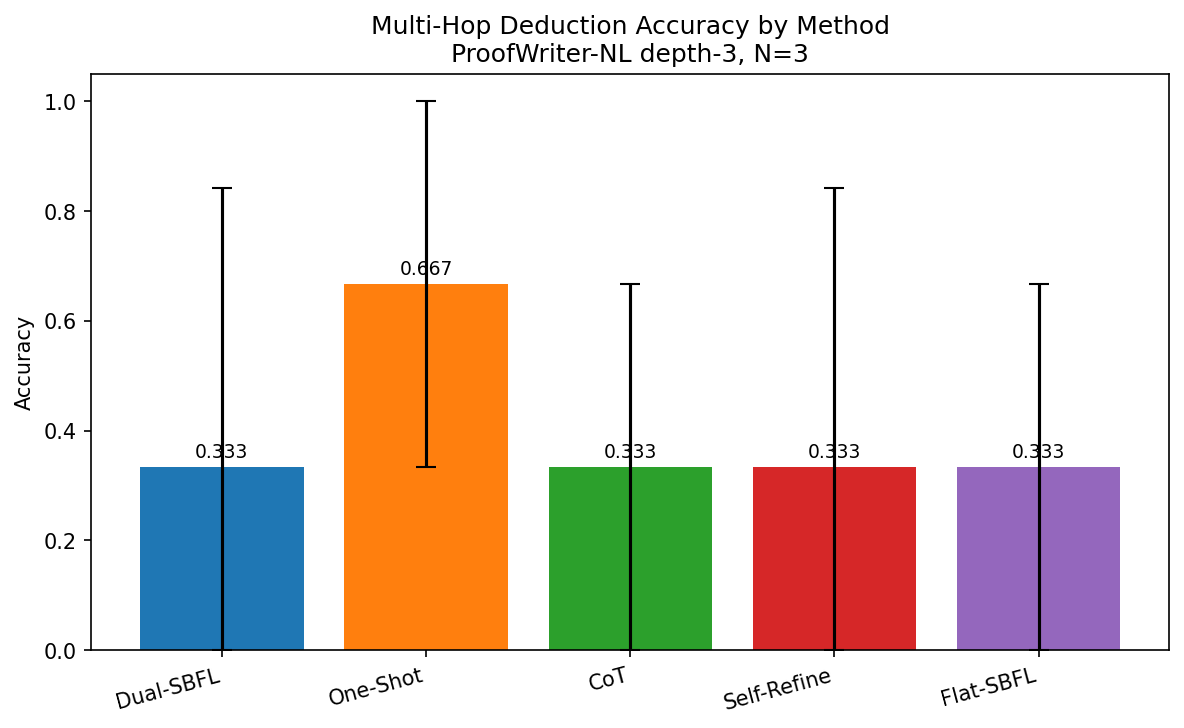


Fig 2: KB Hallucination Rate


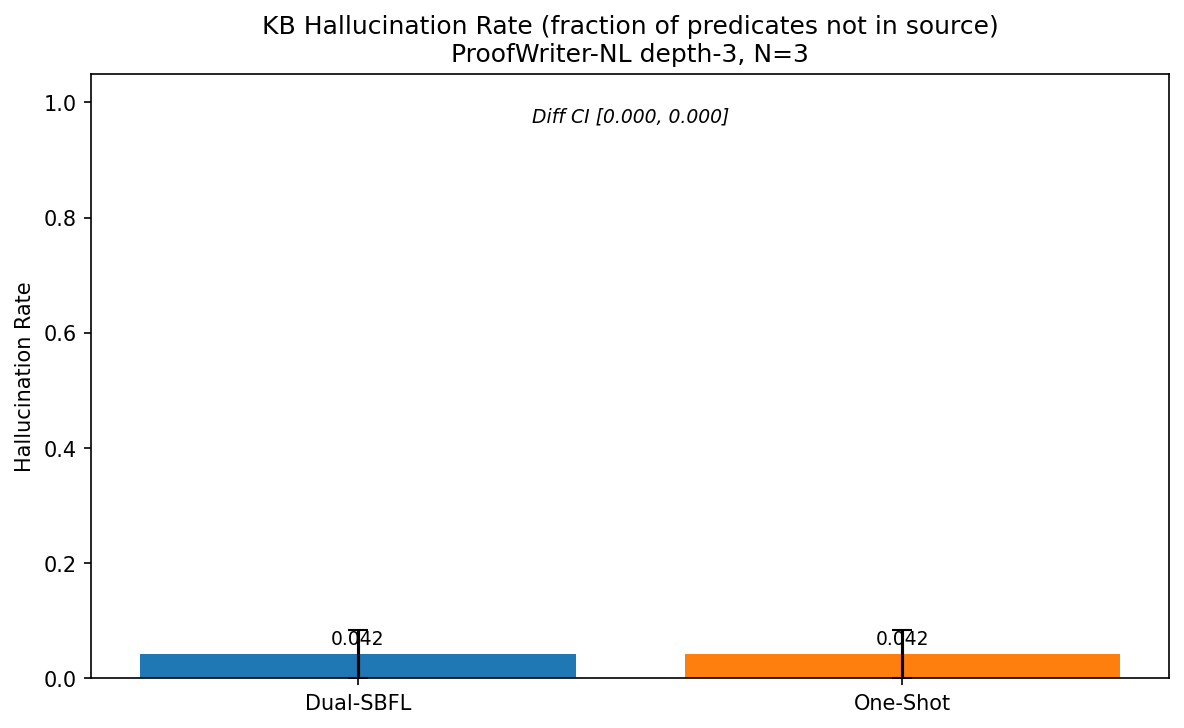


Fig 3: LLM Calls per Document


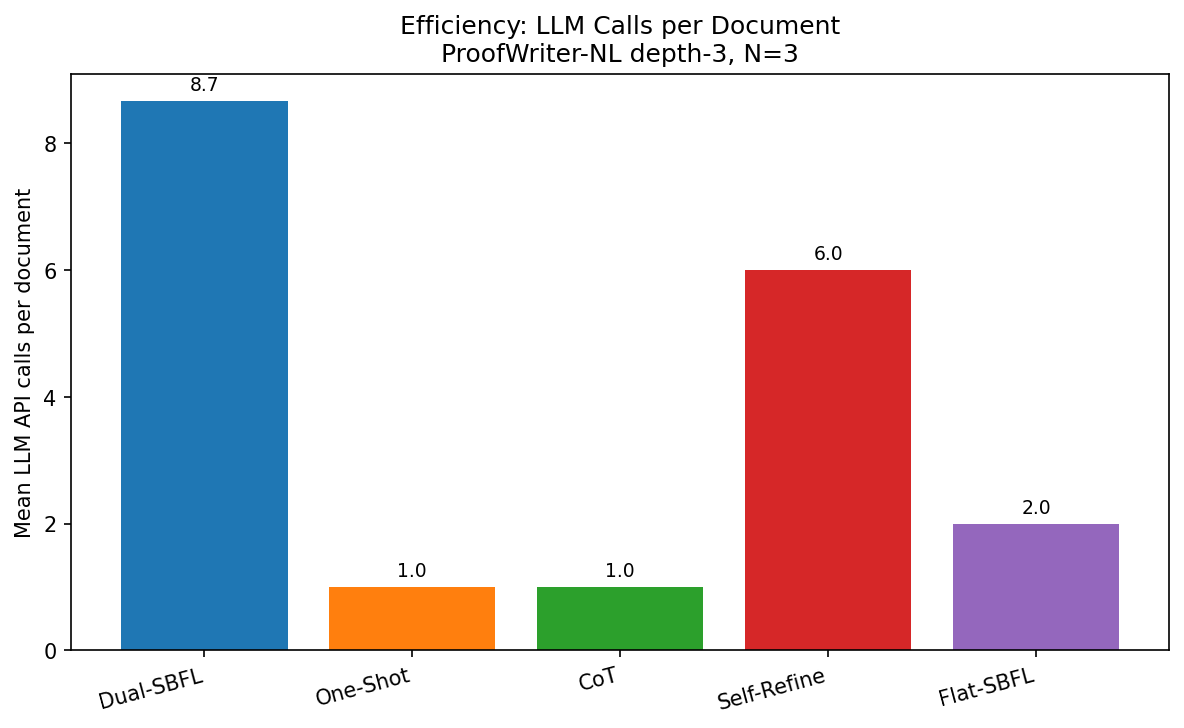


Fig 4: Accuracy vs Hop Depth


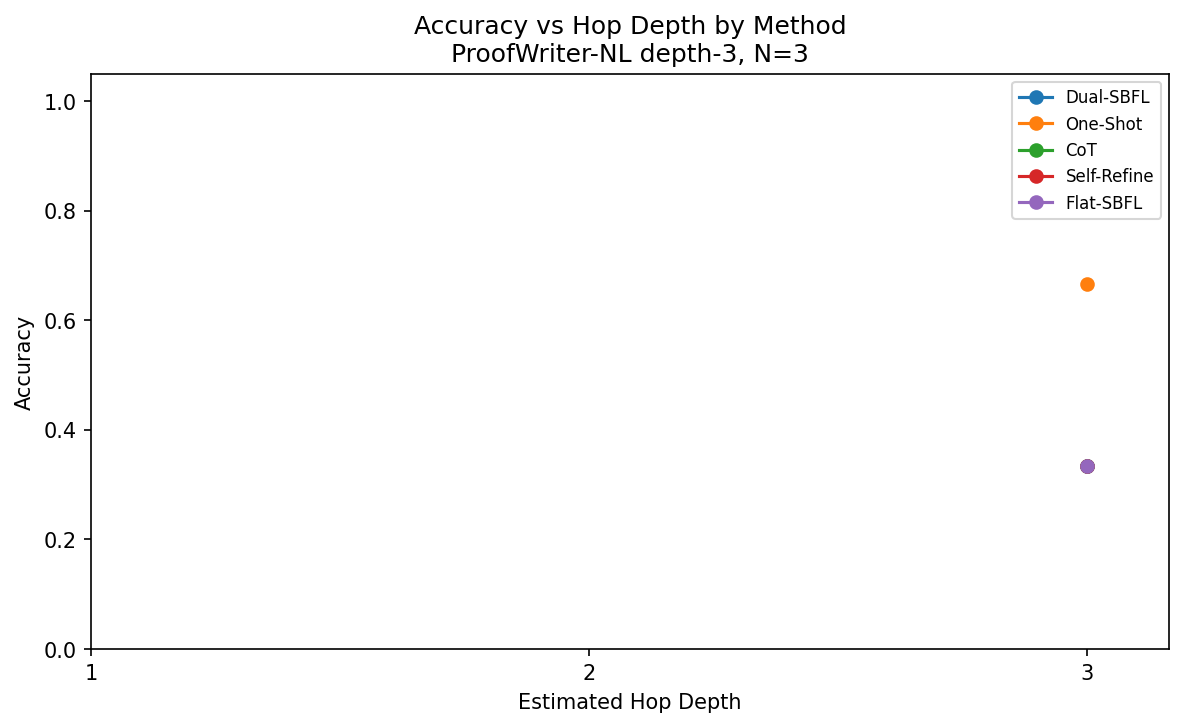


Fig 5: Perturbation Calibration Rho


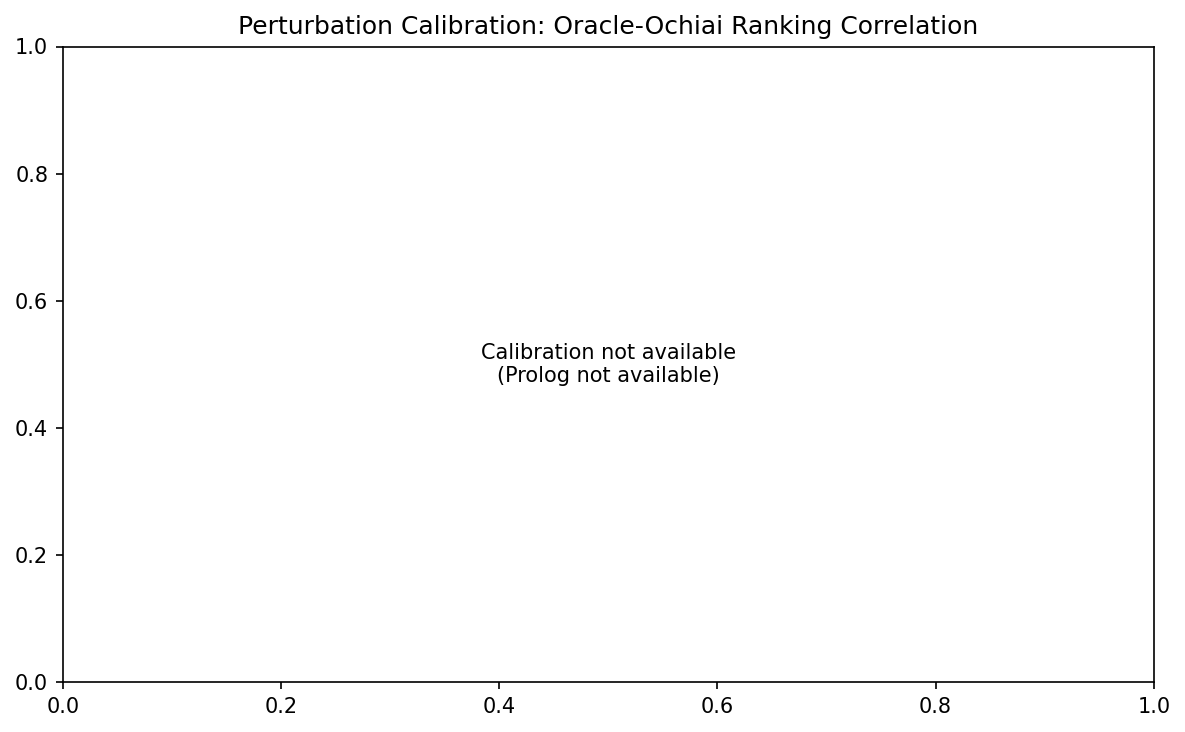


Fig 6: KB Structural Completeness


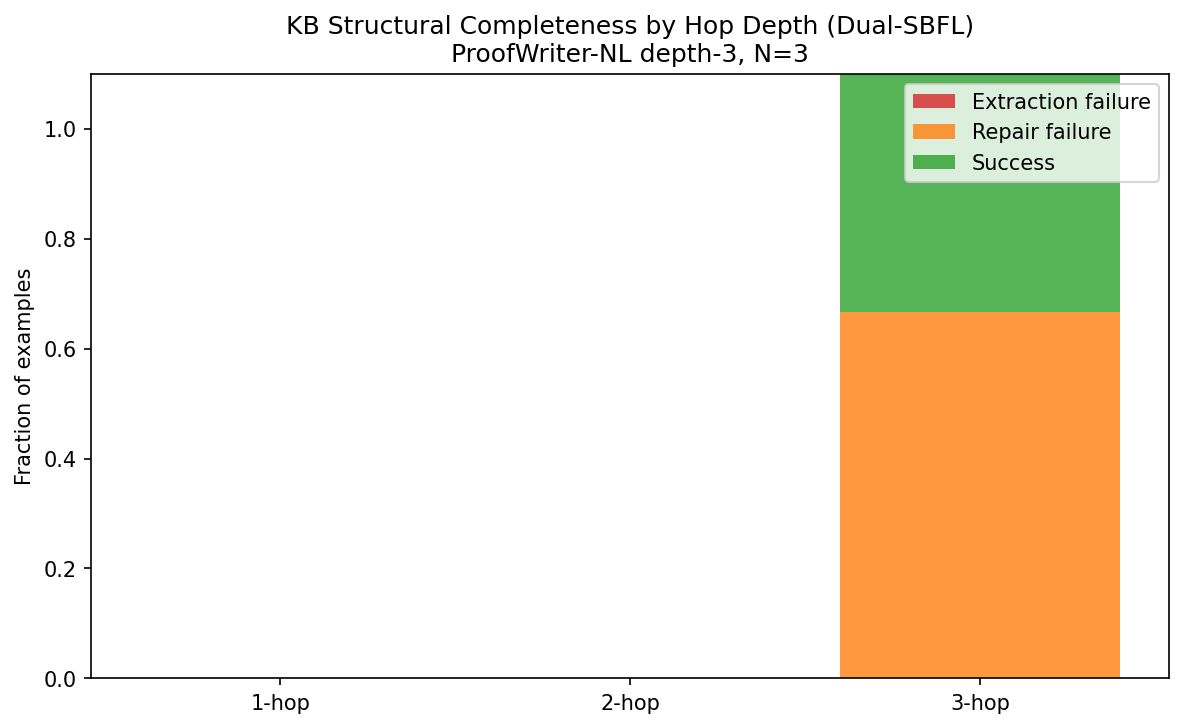


Fig 7: Strict vs Fuzzy Recall


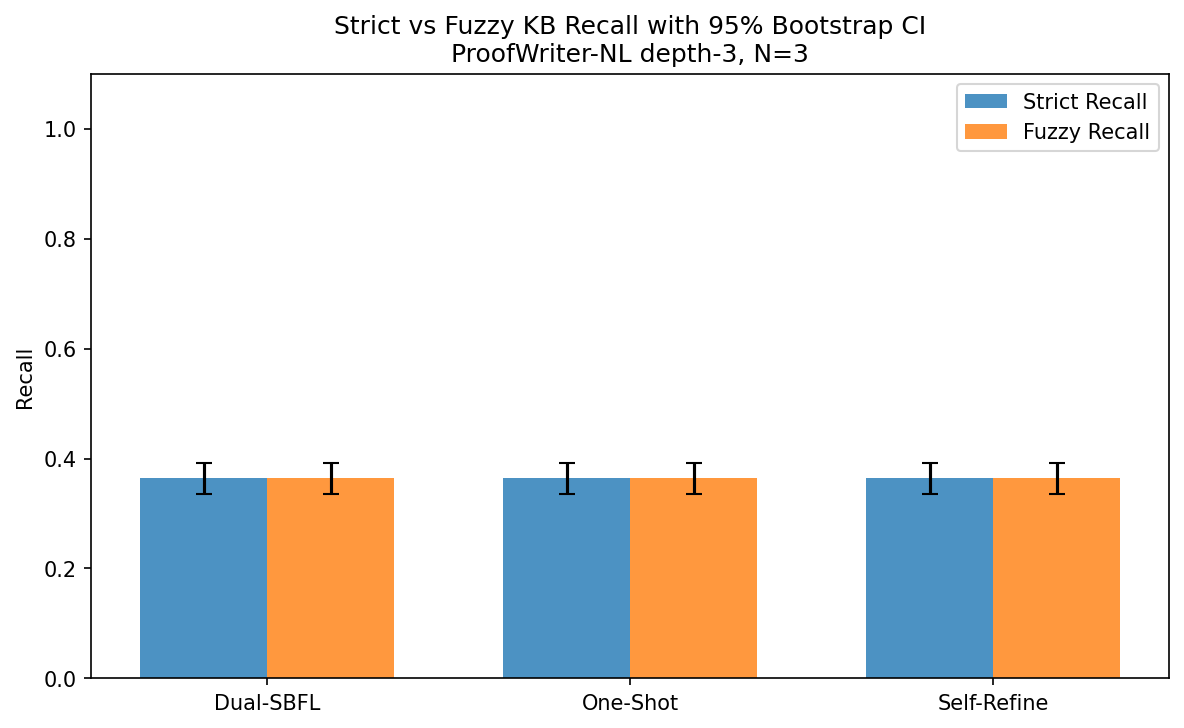

In [13]:
from IPython.display import display, Image

# ── Accuracy table ────────────────────────────────────────────────────────────
print(f"{'Method':<15} {'Accuracy':>9}  {'95% CI (±)':>12}  {'vs Dual-SBFL CI':>22}")
print("-" * 65)
for m, label in zip(METHOD_NAMES, METHOD_LABELS):
    acc = accuracy_by_method[m]
    lo, hi = bootstrap_ci_mean(correct_arrays[m])
    ci_str = f"[{lo:.3f}, {hi:.3f}]"
    if m != "dual_sbfl":
        pair_key = f"dual_sbfl_vs_{m}"
        diff_lo = bootstrap_cis[pair_key]["ci_lo"]
        diff_hi = bootstrap_cis[pair_key]["ci_hi"]
        diff_str = f"[{diff_lo:.3f}, {diff_hi:.3f}]"
    else:
        diff_str = "—"
    print(f"{label:<15} {acc:>9.3f}  {ci_str:>14}  {diff_str:>22}")

print()
print(f"Hallucination — Dual-SBFL: {float(np.mean(hall_dual)):.3f}  |  One-Shot: {float(np.mean(hall_one)):.3f}")
print(f"Hallucination diff CI: [{hall_ci[0]:.3f}, {hall_ci[1]:.3f}]")
print()

# ── Display figures ───────────────────────────────────────────────────────────
fig_paths = [
    ("fig1_accuracy_ci.png", "Fig 1: Accuracy with 95% Bootstrap CI"),
    ("fig2_hallucination.png", "Fig 2: KB Hallucination Rate"),
    ("fig3_efficiency.png", "Fig 3: LLM Calls per Document"),
    ("fig4_hop_depth_accuracy.png", "Fig 4: Accuracy vs Hop Depth"),
    ("fig5_calibration_rho.png", "Fig 5: Perturbation Calibration Rho"),
    ("fig6_kb_completeness.png", "Fig 6: KB Structural Completeness"),
    ("fig7_strict_vs_fuzzy_recall_ci.png", "Fig 7: Strict vs Fuzzy Recall"),
]

for fname, title in fig_paths:
    if os.path.exists(fname):
        print(f"\n{title}")
        display(Image(filename=fname, width=600))